In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qibo.gates import M, X, RY, CZ, I, H
from qibo.models import Circuit
from qiboconnection.api import API
import matplotlib.pyplot as plt

from qiboconnection.connection import ConnectionConfiguration

from benchmarks.utils.qst_qpt_helper_functions import process_returned_dataformat

from itertools import product
from scipy.stats import multivariate_normal
api = API(ConnectionConfiguration(username="vsanchez", api_key="ea712370-7516-4cbf-91a6-72a82e39ba02"))
from scipy import stats

api.select_device_id(9)

In [79]:
def get_chsh_circuits(bell_state, control_qubit, target_qubit, theta):
    assert bell_state in (
        "phi_plus",
        "phi_minus",
        "psi_plus",
        "psi_minus",
    ), "bell_state should be phi_plus, phi_minus, psi_plus, psi_minus"
    nqubits = max(control_qubit, target_qubit) + 1

    circuits = []
    for gate_a, gate_b in product([I, H], repeat=2):
        circuit = Circuit(nqubits)

        if bell_state == "phi_plus" or bell_state == "psi_minus":
            G1 = RY(control_qubit, theta=-np.pi / 2)
        else:
            G1 = RY(control_qubit, theta=np.pi / 2)
        if bell_state == "phi_plus" or bell_state == "phi_minus":
            G2_prime = RY(target_qubit, theta=-np.pi / 2)
        else:
            G2_prime = RY(target_qubit, theta=np.pi / 2)
        ## build bell state
        circuit.add(G1)
        circuit.add(RY(target_qubit, theta=np.pi / 2))
        circuit.add(CZ(control_qubit, target_qubit))
        circuit.add(G2_prime)

        ## decoder part
        circuit.add(RY(control_qubit, theta=theta))
        circuit.add(gate_a(control_qubit))
        circuit.add(gate_b(target_qubit))
        circuit.add(M(control_qubit, target_qubit))

        circuits.append(circuit)

    return circuits


def SPAM_circuits(control_qubit, target_qubit):
    """Circuits to get the SPAM matrix in order to perform measurement correction."""
    calibration_circuits = []
    for gate_a, gate_b in product([I, X], repeat=2):
        calibration_circuit = Circuit(5)
        calibration_circuit.add(gate_a(control_qubit))
        calibration_circuit.add(gate_b(target_qubit))
        calibration_circuit.add(M(control_qubit, target_qubit))

        calibration_circuits.append(calibration_circuit)
    return calibration_circuits


def compute_witnesses(chsh_results, measurement_calibration_weights, BELL_STATE, raw=False, spam_err=None):
    """Returns arrays of computed witness values.

    Args:
        chsh_results (array): matrix containing the probabilities the chsh circuits. It must be
                        of dimensions len(theta_values) x 4 (decoder circuits) x 4 (probabilities)
        measurement_calibration_weights (array): measurement calibration matrix.
        BELL_STATE (string): can be "phi_plus", "phi_minus", "psi_plus" or "psi_minus". It needs
                            to be specified because the witness isn't the same for all 4 Bell states.
        raw (bool): whether or not calculate the witnesses from the raw data instead of applying the
                    measurement corrections. Defaults to False.
    Returns:
        witness1 (array): array length len(theta_values) containing the first witness
        witness2 (array): array length len(theta_values) containing the second witness
    """
    len_theta_values = np.shape(chsh_results)[0]
    witness1 = np.zeros(len_theta_values)
    witness2 = np.zeros(len_theta_values)

    if BELL_STATE in ["phi_plus", "psi_minus"]:
        signs1 = np.array([1, 1, -1, 1])
        signs2 = np.array([1, -1, 1, 1])
    else:
        signs1 = np.array([-1, 1, 1, 1])
        signs2 = np.array([1, 1, 1, -1])

    for i, chsh_result in enumerate(chsh_results):
        if raw is not True:
            # apply measurement calibration
            chsh_result = measurement_calibration_weights @ chsh_result.T
            # calculate expectation values from probabilities
            expectations = np.array([1, -1, -1, 1]).T @ chsh_result
        else:
            # calculate expectation values from probabilities
            expectations = chsh_result @ np.array([1, -1, -1, 1])
        # compute witnesses
        witness1[i] = signs1.T @ expectations
        witness2[i] = signs2.T @ expectations
        expectations_err = np.sum(chsh_result * (spam_err / measurement_calibration_weights)) if spam_err is not None else None

    return witness1, witness2, expectations_err

In [3]:
CONTROL_QUBIT = 2
TARGET_QUBIT = 0
THETA_VALUES = np.linspace(-np.pi, np.pi, num=20)
BELL_STATE = "psi_minus"

NUM_SHOTS = 8000

### Build circuits for CHSH and measurement correction

In [4]:
all_circuits_chsh = []
for theta in THETA_VALUES:
    circuits_th = get_chsh_circuits(BELL_STATE, CONTROL_QUBIT, TARGET_QUBIT, theta)
    all_circuits_chsh.extend(circuits_th)

all_circuits = SPAM_circuits(CONTROL_QUBIT, TARGET_QUBIT)

all_circuits.extend(all_circuits_chsh)

### Run circuits

In [59]:
spam_ids = [api.execute(SPAM_circuits(CONTROL_QUBIT, TARGET_QUBIT), nshots=1000)[0] for _ in range(20)]
# spam_ids = [8714,8715,8716,8717,8718,8719,8720,8721,8722,8723]

In [68]:
spam_probs = [process_returned_dataformat(api.get_result(result_id), nqubits=2) for result_id in spam_ids]

{
  "title": "Unauthorized",
  "status": 401,
  "detail": "JWTExpired: Error verifying the authorisation access token. Expired at 1709130237, time: 1709130396(leeway: 60) 401 Client Error:  for url: https://qilimanjaroqaas.ddns.net:8080/api/v1/jobs/8775"
}
{"title":"Unauthorized","status":401,"detail":"JWTExpired: Error verifying the authorisation access token. Expired at 1709130237, time: 1709130396(leeway: 60)"}

Your job with id 8775 is completed.
Your job with id 8776 is completed.
Your job with id 8777 is completed.
Your job with id 8778 is completed.
Your job with id 8779 is completed.
Your job with id 8780 is completed.
Your job with id 8781 is completed.
Your job with id 8782 is completed.
Your job with id 8783 is completed.
Your job with id 8784 is completed.
Your job with id 8785 is completed.
Your job with id 8786 is completed.
Your job with id 8787 is completed.
Your job with id 8788 is completed.
Your job with id 8789 is completed.
Your job with id 8790 is completed.
Your 

array([[0.72745, 0.138  , 0.11175, 0.0228 ],
       [0.12935, 0.7448 , 0.01975, 0.1061 ],
       [0.11455, 0.02235, 0.7215 , 0.1416 ],
       [0.02425, 0.1191 , 0.1386 , 0.71805]])

In [39]:
# result_id = api.execute(all_circuits, nshots=NUM_SHOTS)[0]
result_id = 8695

In [40]:
results = api.get_job(result_id)
results

{
  "title": "Unauthorized",
  "status": 401,
  "detail": "JWTExpired: Error verifying the authorisation access token. Expired at 1709128245, time: 1709129530(leeway: 60) 401 Client Error:  for url: https://qilimanjaroqaas.ddns.net:8080/api/v1/jobs/8695"
}
{"title":"Unauthorized","status":401,"detail":"JWTExpired: Error verifying the authorisation access token. Expired at 1709128245, time: 1709129530(leeway: 60)"}

Your job with id 8695 is completed.


2024-02-28 15:12:10,283 - qm - INFO     - Starting session: 48d1396e-53b6-4a74-9283-3ca0c91dcecc


JobData(completed_at='2024-02-27T15:40:53.374527+00:00', created_at='2024-02-27T15:39:18.481184+00:00', description=[<qibo.models.circuit.Circuit object at 0x7f03d8203c10>, <qibo.models.circuit.Circuit object at 0x7f03d85f74f0>, <qibo.models.circuit.Circuit object at 0x7f03d8499f00>, <qibo.models.circuit.Circuit object at 0x7f03d849a260>, <qibo.models.circuit.Circuit object at 0x7f03d849a470>, <qibo.models.circuit.Circuit object at 0x7f03d849abf0>, <qibo.models.circuit.Circuit object at 0x7f03d849ada0>, <qibo.models.circuit.Circuit object at 0x7f03d849a800>, <qibo.models.circuit.Circuit object at 0x7f03d849a9b0>, <qibo.models.circuit.Circuit object at 0x7f03d849a590>, <qibo.models.circuit.Circuit object at 0x7f03d849a1a0>, <qibo.models.circuit.Circuit object at 0x7f03d849a500>, <qibo.models.circuit.Circuit object at 0x7f03d84a2200>, <qibo.models.circuit.Circuit object at 0x7f03d84a1a50>, <qibo.models.circuit.Circuit object at 0x7f03d84a2140>, <qibo.models.circuit.Circuit object at 0x7f

### Process real data

In [80]:
## retrieve data
results = api.get_result(result_id)
data_probabilities = process_returned_dataformat(results, nqubits=2)

## measurement calibration data processing
# spam_data_probabilities = data_probabilities[:4]
spam_data_probabilities = np.mean(spam_probs, axis=0)
measurement_calibration_weights = np.linalg.inv(spam_data_probabilities)

## chsh circuits data processing
chsh_data_probabilities = data_probabilities[4:]
chsh_data_probabilities_theta = chsh_data_probabilities.reshape(len(THETA_VALUES), 4, 4)


## compute witness
w1_raw, w2_raw, _ = compute_witnesses(chsh_data_probabilities_theta, measurement_calibration_weights, BELL_STATE, raw=True)
w1_corrected, w2_corrected, spam_err = compute_witnesses(
    chsh_data_probabilities_theta, measurement_calibration_weights, BELL_STATE, raw=False, spam_err = np.std(spam_probs, axis=0)
)

{
  "title": "Unauthorized",
  "status": 401,
  "detail": "JWTExpired: Error verifying the authorisation access token. Expired at 1709130696, time: 1709131398(leeway: 60) 401 Client Error:  for url: https://qilimanjaroqaas.ddns.net:8080/api/v1/jobs/8695"
}
{"title":"Unauthorized","status":401,"detail":"JWTExpired: Error verifying the authorisation access token. Expired at 1709130696, time: 1709131398(leeway: 60)"}

Your job with id 8695 is completed.


### Run simulation, get ideal witnesses

In [45]:
circ_list = SPAM_circuits(0, 1)
ideal_results_spam = np.zeros((len(circ_list), 4))
for i, c in enumerate(circ_list):
    ideal_results_spam[i] += c.execute().probabilities()
ideal_measurement_calibration_weights = np.linalg.inv(ideal_results_spam)

circ_list = list(np.copy(all_circuits_chsh))
ideal_results_chsh = np.zeros((len(circ_list), 4))
for i, c in enumerate(circ_list):
    ideal_results_chsh[i] += c.execute().probabilities()

ideal_results_chsh_theta = ideal_results_chsh.reshape(len(THETA_VALUES), 4, 4)

w1_ideal, w2_ideal = compute_witnesses(
    ideal_results_chsh_theta, ideal_measurement_calibration_weights, BELL_STATE, raw=False
)

[Qibo 0.1.12.dev0|INFO|2024-02-28 15:16:10]: Using numpy backend on /CPU:0


### Get error bars

In [46]:
# def return_mock_results():
#     # returns simulated results using distribution from experimental results' probabilities
#     mock_results = data_probabilities[4:].copy()
#     measurement_calibration_weights = np.linalg.inv(data_probabilities[:4])    
#     for i, _ in enumerate(mock_results):        
#         mock_results[i] = stats.multinomial.rvs(NUM_SHOTS, mock_results[i]) / NUM_SHOTS

#     return list((compute_witnesses(mock_results.reshape(-1, 4, 4), measurement_calibration_weights, BELL_STATE, raw=False) +
#             compute_witnesses(mock_results.reshape(-1, 4, 4), measurement_calibration_weights, BELL_STATE, raw=True)))
    
# def get_err_bars(mock_results):
#     data_hist = np.stack(mock_results)
#     err_bars = np.empty(len(data_hist.T))
#     for i, hist in enumerate(data_hist.T):
#         _ , var = stats.norm.fit(hist)
#         err_bars[i] =np.sqrt(var)
#     return err_bars

# # generate n copies of random results
# err_w1, err_w2, err_w1_unc, err_w2_unc  = [get_err_bars(mock_results) for mock_results in zip(*[return_mock_results() for _ in range(NUM_SHOTS)])]

### Plot results

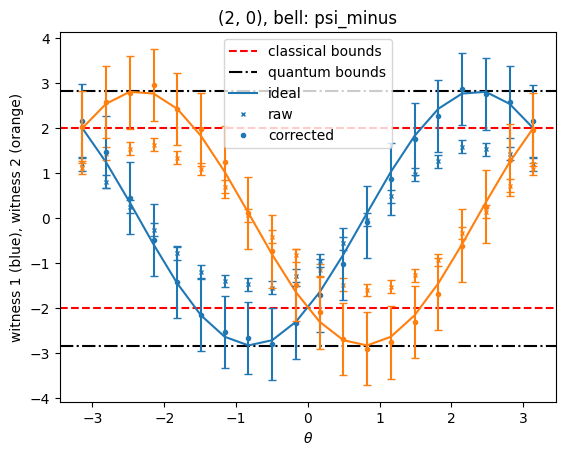

In [89]:
fname = f"chsh_{CONTROL_QUBIT}_{TARGET_QUBIT}_{BELL_STATE}_nshots{NUM_SHOTS}_jobid{result_id}.png"
savefig = False

fig, ax = plt.subplots()
ax.axhline(2, color="red", linestyle="--", label="classical bounds")
ax.axhline(-2, color="red", linestyle="--")
ax.axhline(2 * np.sqrt(2), color="k", linestyle="-.", label="quantum bounds")
ax.axhline(-2 * np.sqrt(2), color="k", linestyle="-.")

ax.plot(THETA_VALUES, w1_ideal, label="ideal")
ax.plot(THETA_VALUES, w2_ideal)

ax.plot(THETA_VALUES, w1_raw, "x", ms=3, c="C0", label="raw")
ax.errorbar(THETA_VALUES, w1_raw, err_w1_unc, capsize=3, c="C0", ls="none")

ax.plot(THETA_VALUES, w2_raw, "x", ms=3, c="C1")
ax.errorbar(THETA_VALUES, w2_raw, err_w2_unc, capsize=3, c="C1", ls="none")

ax.plot(THETA_VALUES, w1_corrected, ".", c="C0", label="corrected")
ax.errorbar(THETA_VALUES, w1_corrected, np.sqrt(err_w1**2 + spam_err**2), capsize=3, c="C0", ls="none")

ax.plot(THETA_VALUES, w2_corrected, ".", c="C1")
ax.errorbar(THETA_VALUES, w2_corrected, np.sqrt(err_w2**2 + spam_err**2), capsize=3, c="C1", ls="none")

ax.legend()

ax.set_xlabel("$\\theta$")
ax.set_ylabel("witness 1 (blue), witness 2 (orange)")

ax.set_title(f"({CONTROL_QUBIT}, {TARGET_QUBIT}), bell: {BELL_STATE}")
if savefig:
    fig.savefig(fname, bbox_inches="tight")